# ARIMA Feature Extraction

**Docker image**: `ml4t`

This notebook demonstrates ARIMA as a **feature extractor** rather than a
standalone forecaster. The output is the ARIMA point forecast, evaluated as a
predictive feature (IC/RMSE) across orders and symbols.

**Learning Objectives**:
- Select ARIMA order using ACF/PACF and information criteria (AIC/BIC)
- Build ARIMA point forecasts and evaluate them as features (IC, RMSE)
- Compare AR, AIC-selected, and naive baselines across the ETF universe
- Diagnose why simple ARIMA mean models extract limited signal from daily returns

**Book Reference**: Chapter 9, Section 9.3 (Volatility Features)

**Prerequisites**: `01_visual_diagnostics` for stationarity testing,
`03_fractional_differencing` for memory-preserving transforms.

## 1. Setup and Imports

In [1]:
"""ARIMA Feature Extraction - build ARIMA point forecasts and evaluate them as features (IC/RMSE)."""

import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from ml4t.diagnostic.evaluation.autocorrelation import analyze_autocorrelation
from ml4t.diagnostic.evaluation.stationarity import analyze_stationarity
from ml4t.diagnostic.metrics import pooled_ic
from plotly.subplots import make_subplots
from scipy.stats import ConstantInputWarning
from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning,
    InterpolationWarning,
    ValueWarning,
)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, adfuller, pacf

# Silence known-benign modeling noise (no-frequency date index, non-convergent grid
# fits, constant-input IC, KPSS interpolation) so outputs stay clean.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=ConstantInputWarning)

from data import load_etfs
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS  # sets the ml4t Plotly template as the default

In [2]:
# Production defaults - Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all symbols
START_DATE = "2015-01-01"
END_DATE = "2024-12-01"
TEST_START = "2024-01-01"
SEED = 42

In [3]:
set_global_seeds(SEED)

# Configuration

# ETF symbols
etf_data = load_etfs()
ALL_SYMBOLS = etf_data["symbol"].unique().sort().to_list()
SYMBOLS = ALL_SYMBOLS[:MAX_SYMBOLS] if MAX_SYMBOLS > 0 else ALL_SYMBOLS

# For single-symbol demonstration (used in educational sections)
SYMBOL = "SPY"

print("ARIMA Baseline Configuration:")
print(f"  Symbols: {len(SYMBOLS)} ({', '.join(SYMBOLS)})")
print(f"  Train: {START_DATE} to {TEST_START}")
print(f"  Test: {TEST_START} to {END_DATE}")

ARIMA Baseline Configuration:
  Symbols: 100 (ACWI, ACWX, AGG, BIL, BND, BNDX, DBA, DBC, DIA, DVY, EEM, EFA, EMB, EWA, EWC, EWG, EWH, EWI, EWJ, EWL, EWN, EWP, EWQ, EWT, EWU, EWW, EWY, EWZ, EZA, FXB, FXE, FXI, FXY, GLD, GOVT, GSG, HYG, IAU, IBB, IEF, IEFA, IEMG, IJR, INDA, ITA, ITB, IVE, IVW, IWM, IYR, JNK, KRE, LQD, MCHI, MDY, MTUM, MUB, OIH, PPLT, QQQ, QUAL, RSP, SCHD, SDY, SHY, SLV, SMH, SOXX, SPY, THD, TIP, TLT, UNG, USMV, USO, UUP, VCSH, VEA, VGK, VIG, VLUE, VNQ, VTI, VTV, VUG, VWO, XBI, XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY, XME, XRT)
  Train: 2015-01-01 to 2024-01-01
  Test: 2024-01-01 to 2024-12-01


## 2. Load ETF Price Data

Load from ETF universe for cross-chapter consistency.

In [4]:
# Filter ETF data to date range (once, for all symbols)
start_dt = pl.col("timestamp") >= pl.lit(START_DATE).str.to_date()
end_dt = pl.col("timestamp") <= pl.lit(END_DATE).str.to_date()
etf_data = etf_data.filter(start_dt & end_dt)

print(f"  ETF data: {len(etf_data):,} observations across {etf_data['symbol'].n_unique()} assets")


def get_symbol_data(symbol: str) -> pd.DataFrame:
    """Extract single symbol from pre-loaded ETF data.

    Uses the already-loaded etf_data for efficiency.
    """
    data = (
        etf_data.filter(pl.col("symbol") == symbol)
        .sort("timestamp")
        .with_columns(returns=pl.col("close").pct_change())
        .drop_nulls()
    )

    # Convert to pandas with date index (statsmodels expects pandas)
    # NOTE: statsmodels ARIMA requires pandas DataFrame with DatetimeIndex
    df = data.select(["timestamp", "close", "returns"]).to_pandas()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp")

    return df


print(f"Loading {SYMBOL} data from ETF universe...")
df = get_symbol_data(SYMBOL)
print(f"  Observations: {len(df)}")
print(f"  Date range: {df.index.min().date()} to {df.index.max().date()}")

  ETF data: 248,436 observations across 100 assets
Loading SPY data from ETF universe...
  Observations: 2494
  Date range: 2015-01-05 to 2024-11-29


## 3. Stationarity Testing

ARIMA requires stationary series. We test prices (non-stationary) and returns (stationary).

In [5]:
print("Augmented Dickey-Fuller Test for Stationarity:")
print("-" * 50)

# Test prices
adf_price = adfuller(df["close"].dropna())
print(f"Prices:   ADF={adf_price[0]:.4f}, p={adf_price[1]:.4f}")
print(f"          {'STATIONARY' if adf_price[1] < 0.05 else 'NON-STATIONARY'}")

# Test returns
adf_ret = adfuller(df["returns"].dropna())
print(f"Returns:  ADF={adf_ret[0]:.4f}, p={adf_ret[1]:.4f}")
print(f"          {'STATIONARY' if adf_ret[1] < 0.05 else 'NON-STATIONARY'}")

print("\n→ We model RETURNS (stationary), not prices.")

Augmented Dickey-Fuller Test for Stationarity:
--------------------------------------------------
Prices:   ADF=1.3058, p=0.9966
          NON-STATIONARY
Returns:  ADF=-15.8027, p=0.0000
          STATIONARY

→ We model RETURNS (stationary), not prices.


## 4. ACF/PACF Analysis

ACF helps identify MA order (q), PACF helps identify AR order (p).

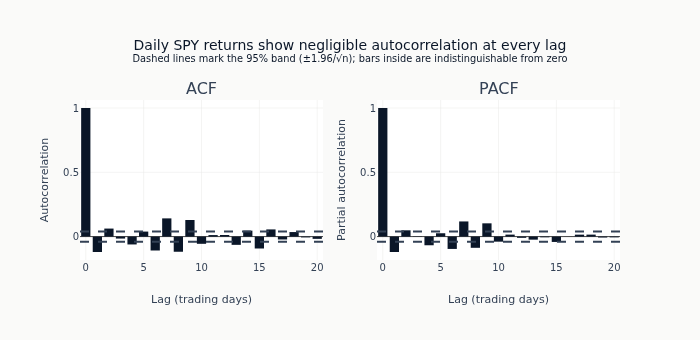


ACF/PACF Interpretation:
  - Returns show little autocorrelation (efficient market)
  - Low ACF/PACF suggests AR(0) or AR(1) may suffice
  - This is typical: returns are hard to predict from past returns


In [6]:
def plot_acf_pacf(series: pd.Series, title: str):
    """Plot ACF and PACF for a series."""
    acf_vals = acf(series.dropna(), nlags=20)
    pacf_vals = pacf(series.dropna(), nlags=20)

    fig = make_subplots(rows=1, cols=2, subplot_titles=("ACF", "PACF"))

    # ACF
    fig.add_trace(
        go.Bar(x=list(range(len(acf_vals))), y=acf_vals, name="ACF", marker_color=COLORS["blue"]),
        row=1,
        col=1,
    )

    # PACF
    fig.add_trace(
        go.Bar(
            x=list(range(len(pacf_vals))), y=pacf_vals, name="PACF", marker_color=COLORS["blue"]
        ),
        row=1,
        col=2,
    )

    # 95% significance bands (±1.96/√n): coefficients inside are noise
    n = len(series)
    sig = 1.96 / np.sqrt(n)
    for col in [1, 2]:
        fig.add_hline(y=sig, line_dash="dash", line_color=COLORS["neutral"], row=1, col=col)
        fig.add_hline(y=-sig, line_dash="dash", line_color=COLORS["neutral"], row=1, col=col)

    fig.update_xaxes(title_text="Lag (trading days)", row=1, col=1)
    fig.update_xaxes(title_text="Lag (trading days)", row=1, col=2)
    fig.update_yaxes(title_text="Autocorrelation", row=1, col=1)
    fig.update_yaxes(title_text="Partial autocorrelation", row=1, col=2)
    fig.update_layout(
        height=340,
        title_text=title,
        showlegend=False,
    )
    return fig


fig = plot_acf_pacf(
    df["returns"],
    f"Daily {SYMBOL} returns show negligible autocorrelation at every lag"
    "<br><sup>Dashed lines mark the 95% band (±1.96/√n); bars inside are indistinguishable from zero</sup>",
)
fig.show()

print("\nACF/PACF Interpretation:")
print("  - Returns show little autocorrelation (efficient market)")
print("  - Low ACF/PACF suggests AR(0) or AR(1) may suffice")
print("  - This is typical: returns are hard to predict from past returns")

### ml4t-diagnostic: Automated Order Suggestion

The manual ACF/PACF interpretation above requires visual inspection.
`analyze_autocorrelation()` examines significant lags programmatically
and suggests an ARIMA order - a useful sanity check before grid search.

In [7]:
stat_check = analyze_stationarity(df["returns"].dropna().values)
acf_analysis = analyze_autocorrelation(df["returns"].dropna().values)

print("=== ml4t-diagnostic: Pre-Modeling Diagnostics ===")
print(f"Stationarity: {stat_check.consensus} (agreement: {stat_check.agreement_score:.2f})")
print(f"Suggested ARIMA order: {acf_analysis.suggested_arima_order}")

2026-07-14 05:23:54,341 - ml4t.diagnostic.evaluation.stationarity.analysis - INFO - Running comprehensive stationarity analysis (n_obs=2494 tests=['adf', 'kpss', 'pp'] alpha=0.05)


2026-07-14 05:23:54,342 - ml4t.diagnostic.evaluation.stationarity.augmented_dickey_fuller - INFO - Running ADF test (n_obs=2494 maxlag=None regression=c autolag=AIC)


2026-07-14 05:23:54,384 - ml4t.diagnostic.evaluation.stationarity.augmented_dickey_fuller - INFO - ADF test completed (statistic=-15.802707807332968 p_value=1.0693651813551915e-28 lags_used=9 n_obs=2484 stationary=True)


2026-07-14 05:23:54,384 - ml4t.diagnostic.evaluation.stationarity.analysis - INFO - ADF test completed (stationary=True)


2026-07-14 05:23:54,385 - ml4t.diagnostic.evaluation.stationarity.kpss_test - INFO - Running KPSS test (n_obs=2494 regression=c nlags=auto)


...

2026-07-14 05:23:54,392 - ml4t.diagnostic.evaluation.autocorrelation - INFO - Starting autocorrelation analysis


2026-07-14 05:23:54,393 - ml4t.diagnostic.evaluation.autocorrelation - INFO - ACF computed (n_obs=2494 nlags=33 significant=14)


2026-07-14 05:23:54,400 - ml4t.diagnostic.evaluation.autocorrelation - INFO - PACF computed (n_obs=2494 nlags=33 significant=11)


2026-07-14 05:23:54,401 - ml4t.diagnostic.evaluation.autocorrelation - INFO - Autocorrelation analysis completed (arima_order=(2, 0, 2) white_noise=False)


=== ml4t-diagnostic: Pre-Modeling Diagnostics ===
Stationarity: strong_stationary (agreement: 1.00)
Suggested ARIMA order: (2, 0, 2)


The diagnostic confirms returns are stationary (no differencing needed, d=0)
and suggests a low-order ARIMA - consistent with the efficient market
expectation of minimal autocorrelation in returns.

## 5. Train/Test Split

In [8]:
# Split at TEST_START
test_start_dt = pd.Timestamp(TEST_START)
train = df[df.index < test_start_dt]
test = df[df.index >= test_start_dt]

print(f"Train: {len(train)} obs ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test)} obs ({test.index.min().date()} to {test.index.max().date()})")

Train: 2263 obs (2015-01-05 to 2023-12-29)
Test:  231 obs (2024-01-02 to 2024-11-29)


## 6. Baseline Models

In [9]:
results = {}


# Model 1: Naive (predict last value = 0 for returns)
def naive_forecast(train_ret, n_forecast):
    """Naive forecast: predict 0 (random walk for prices = 0 for returns)."""
    return np.zeros(n_forecast)


naive_pred = naive_forecast(train["returns"], len(test))
naive_ic = pooled_ic(test["returns"].values, naive_pred)
naive_rmse = np.sqrt(np.mean((test["returns"].values - naive_pred) ** 2))

results["Naive (0)"] = {"ic": naive_ic, "rmse": naive_rmse, "predictions": naive_pred}
print("Model 1: Naive (predict 0)")
print(f"  IC: {naive_ic:.4f}, RMSE: {naive_rmse:.6f}")

Model 1: Naive (predict 0)
  IC: nan, RMSE: 0.007866


In [10]:
# Model 2: Naive (predict mean)
def mean_forecast(train_ret, n_forecast):
    """Predict historical mean."""
    return np.full(n_forecast, train_ret.mean())


mean_pred = mean_forecast(train["returns"], len(test))
mean_ic = pooled_ic(test["returns"].values, mean_pred)
mean_rmse = np.sqrt(np.mean((test["returns"].values - mean_pred) ** 2))

results["Mean"] = {"ic": mean_ic, "rmse": mean_rmse, "predictions": mean_pred}
print("\nModel 2: Historical Mean")
print(f"  IC: {mean_ic:.4f}, RMSE: {mean_rmse:.6f}")


Model 2: Historical Mean
  IC: nan, RMSE: 0.007811


## 7. AR Models

In [11]:
# Model 3: AR(1)
print("\nModel 3: AR(1)")
ar1 = ARIMA(train["returns"], order=(1, 0, 0))
ar1_fit = ar1.fit()
ar1_pred = ar1_fit.forecast(steps=len(test))

ar1_ic = pooled_ic(test["returns"].values, ar1_pred.values)
ar1_rmse = np.sqrt(np.mean((test["returns"].values - ar1_pred.values) ** 2))

results["AR(1)"] = {"ic": ar1_ic, "rmse": ar1_rmse, "predictions": ar1_pred.values}
print(f"  AR(1) coef: {ar1_fit.params.get('ar.L1', ar1_fit.params.iloc[1]):.4f}")
print(f"  IC: {ar1_ic:.4f}, RMSE: {ar1_rmse:.6f}")

# Model 4: AR(5)
print("\nModel 4: AR(5)")
ar5 = ARIMA(train["returns"], order=(5, 0, 0))
ar5_fit = ar5.fit()
ar5_pred = ar5_fit.forecast(steps=len(test))

ar5_ic = pooled_ic(test["returns"].values, ar5_pred.values)
ar5_rmse = np.sqrt(np.mean((test["returns"].values - ar5_pred.values) ** 2))

results["AR(5)"] = {"ic": ar5_ic, "rmse": ar5_rmse, "predictions": ar5_pred.values}
print(f"  IC: {ar5_ic:.4f}, RMSE: {ar5_rmse:.6f}")


Model 3: AR(1)


  AR(1) coef: -0.1269
  IC: 0.0655, RMSE: 0.007813

Model 4: AR(5)


  IC: -0.0255, RMSE: 0.007813


## 8. ARIMA Model Selection

We search over a grid of (p, d, q) and select based on AIC/BIC.

In [12]:
print("\nModel Selection: Grid Search")
print("-" * 50)

best_aic = np.inf
best_order = None
best_model = None

# Grid search (limited for speed)
p_range = range(0, 4)
q_range = range(0, 3)
d = 0  # Returns are already stationary

model_results = []

for p in p_range:
    for q in q_range:
        try:
            model = ARIMA(train["returns"], order=(p, d, q))
            fit = model.fit()
            model_results.append({"p": p, "q": q, "aic": fit.aic, "bic": fit.bic})

            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, d, q)
                best_model = fit
        except (ValueError, np.linalg.LinAlgError):
            continue

if model_results:
    model_df = pd.DataFrame(model_results).sort_values("aic")
    print("Top 5 models by AIC:")
    display(model_df.head())

    print(f"Best model: ARIMA{best_order} (AIC: {best_aic:.2f})")


Model Selection: Grid Search
--------------------------------------------------


Top 5 models by AIC:


,p,q,aic,bic
11,3,2,-13895.574644,-13855.503518
6,2,0,-13863.931048,-13841.033261
2,0,2,-13863.824910,-13840.927124
9,3,0,-13861.931354,-13833.309121
7,2,1,-13861.929287,-13833.307054


Best model: ARIMA(3, 0, 2) (AIC: -13895.57)


In [13]:
# Forecast with best model
if best_model:
    best_pred = best_model.forecast(steps=len(test))
    best_ic = pooled_ic(test["returns"].values, best_pred.values)
    best_rmse = np.sqrt(np.mean((test["returns"].values - best_pred.values) ** 2))

    results[f"ARIMA{best_order}"] = {
        "ic": best_ic,
        "rmse": best_rmse,
        "predictions": best_pred.values,
    }
    print(f"\nBest ARIMA{best_order}:")
    print(f"  IC: {best_ic:.4f}, RMSE: {best_rmse:.6f}")


Best ARIMA(3, 0, 2):
  IC: -0.0495, RMSE: 0.007829


## 9. Rolling Forecast (Walk-Forward)

For a more realistic evaluation, we use rolling 1-step-ahead forecasts.

In [14]:
print("\nRolling 1-Step-Ahead Forecast (Walk-Forward):")
print("-" * 50)

# Rolling forecast with AR(1)
rolling_preds = []
rolling_actuals = []

# Initial training window
window_size = len(train)
full_returns = df["returns"].values

# Rolling forecast iterations
n_rolling = len(test)

for i in range(n_rolling):
    # Fit on expanding window
    train_window = full_returns[: window_size + i]

    # Quick AR(1) fit; statsmodels can fail on rank-deficient or non-stationary
    # windows - fall back to zero forecast in that rare case.
    try:
        model = ARIMA(train_window, order=(1, 0, 0))
        fit = model.fit()
        pred = fit.forecast(steps=1)[0]
    except (ValueError, np.linalg.LinAlgError):
        pred = 0.0

    rolling_preds.append(pred)
    rolling_actuals.append(full_returns[window_size + i])

rolling_preds = np.array(rolling_preds)
rolling_actuals = np.array(rolling_actuals)

rolling_ic = pooled_ic(rolling_actuals, rolling_preds)
rolling_rmse = np.sqrt(np.mean((rolling_actuals - rolling_preds) ** 2))

results["AR(1) Rolling"] = {"ic": rolling_ic, "rmse": rolling_rmse, "predictions": rolling_preds}
print(f"AR(1) Rolling IC: {rolling_ic:.4f}, RMSE: {rolling_rmse:.6f}")


Rolling 1-Step-Ahead Forecast (Walk-Forward):
--------------------------------------------------


AR(1) Rolling IC: 0.0178, RMSE: 0.007897


## 10. Results Comparison

In [15]:
summary_rows = [{"model": name, "ic": r["ic"], "rmse": r["rmse"]} for name, r in results.items()]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# Best model by IC (skip NaN entries - constant predictions yield undefined IC)
finite = summary_df[summary_df["ic"].notna()]
if not finite.empty:
    best_row = finite.loc[finite["ic"].idxmax()]
    print(
        f"Best by IC (excluding constant predictions): {best_row['model']} ({best_row['ic']:.4f})"
    )

,model,ic,rmse
0,Naive (0),NaN,0.007866
1,Mean,NaN,0.007811
2,AR(1),0.065527,0.007813
3,AR(5),-0.025470,0.007813
4,"ARIMA(3, 0, 2)",-0.049523,0.007829
5,AR(1) Rolling,0.017792,0.007897


Best by IC (excluding constant predictions): AR(1) (0.0655)


## 11. Visualization

In [16]:
# Plot comparison (returns shown in %; static multi-step forecasts are out-of-sample)
models_to_plot = ["Naive (0)", "AR(1)", f"ARIMA{best_order}" if best_order else "AR(1)"]
model_colors = {
    "Naive (0)": COLORS["copper"],
    "AR(1)": COLORS["blue"],
    f"ARIMA{best_order}": COLORS["amber"],
}

fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=(
        "Forecasts flatten within days; realized returns keep moving",
        "The AR(1) forecast distribution is a spike next to the return distribution",
    ),
)

# Sample of actual vs predicted
n_plot = min(100, len(test))

fig.add_trace(
    go.Scatter(
        x=list(range(n_plot)),
        y=test["returns"].values[:n_plot] * 100,
        name="Actual",
        line=dict(color=COLORS["neutral"]),
    ),
    row=1,
    col=1,
)

for model_name in models_to_plot:
    if model_name in results:
        fig.add_trace(
            go.Scatter(
                x=list(range(n_plot)),
                y=results[model_name]["predictions"][:n_plot] * 100,
                name=model_name,
                line=dict(color=model_colors.get(model_name, COLORS["copper"]), dash="dot"),
            ),
            row=1,
            col=1,
        )

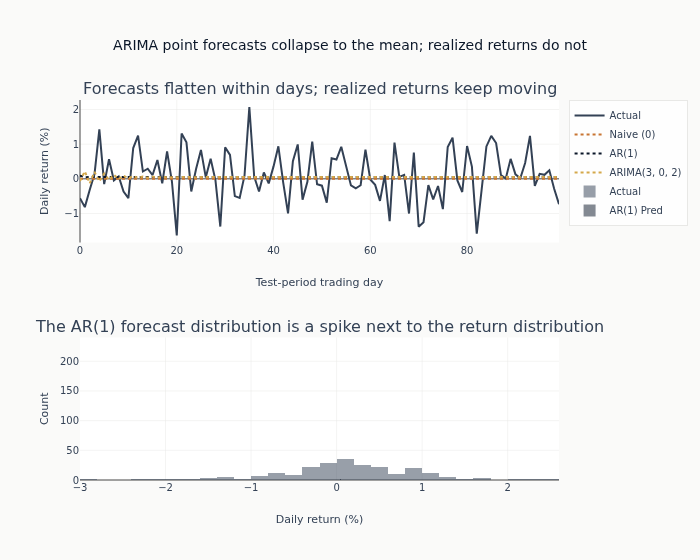

In [17]:
# Histograms
fig.add_trace(
    go.Histogram(
        x=test["returns"].values * 100,
        name="Actual",
        opacity=0.5,
        nbinsx=50,
        marker_color=COLORS["neutral"],
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Histogram(
        x=results["AR(1)"]["predictions"] * 100,
        name="AR(1) Pred",
        opacity=0.5,
        nbinsx=50,
        marker_color=COLORS["blue"],
    ),
    row=2,
    col=1,
)

fig.update_xaxes(title_text="Test-period trading day", row=1, col=1)
fig.update_yaxes(title_text="Daily return (%)", row=1, col=1)
fig.update_xaxes(title_text="Daily return (%)", row=2, col=1)
fig.update_yaxes(title_text="Count", row=2, col=1)
fig.update_layout(
    height=560,
    title_text="ARIMA point forecasts collapse to the mean; realized returns do not",
    barmode="overlay",
)
fig.show()

**Reading the table.** AR(1) on this train/test split lands a small positive
IC (≈ +0.07), which is the most that any single-asset ARIMA model produces
here. The AIC-best ARIMA - `ARIMA(3, 0, 2)` - flips sign and lands a small
*negative* IC; AR(5) is also negative. This is a useful illustration of two
things at once: longer AR/MA orders overfit in-sample at the cost of OOS
rank correlation, and the AIC-best model is not the IC-best model. The
Naive (0) and Mean baselines have constant predictions, so their IC is
undefined (NaN) - they are RMSE benchmarks, not rank-correlation
benchmarks.

**Why ARIMA struggles with returns on this dataset**:
1. **Low autocorrelation**: the ACF of daily SPY returns is statistically
   indistinguishable from zero at most lags, leaving little linear structure
   for an ARIMA mean model to exploit
2. **Heteroskedasticity**: variance changes over time, so a constant-variance
   mean model is misspecified (GARCH addresses this in `08_garch_volatility`)

**When ARIMA works**:
- Trending series (moving averages, cumulative metrics)
- Seasonal patterns (explicit or multiplicative)
- Non-financial time series (weather, sales, etc.)

## 12. Multi-Symbol ARIMA Forecasting

Apply the rolling 1-step-ahead walk-forward from Section 9 to every symbol and
collect the predictions as a standardized feature file for downstream chapters.
Each symbol fits AR(1) once on its training window, then rolls one day ahead
through the test period using the actual most recent return, so the saved feature
varies over time rather than collapsing to a per-symbol constant (which is what a
single static multi-step forecast would produce).

In [18]:
print("\n" + "=" * 60)
print("MULTI-SYMBOL ARIMA FORECASTING")
print("=" * 60)


def run_arima_for_symbol(symbol: str) -> tuple[pl.DataFrame | None, dict]:
    """Run a rolling 1-step-ahead AR(1) walk-forward for a single symbol.

    We fit AR(1) once on the training window and then roll one step ahead through
    the test period, each prediction using the actual most recent return:
    ``y_hat_t = mu + phi * (y_{t-1} - mu)``. This is causal (every input precedes
    its target) and genuinely time-varying, so it does not collapse the way a single
    static multi-step forecast (``fit.forecast(steps=len(test))``) does - that
    collapses to the unconditional mean within a few steps for an AR(1) on returns,
    yielding a near-constant, degenerate feature.

    This is the fixed-parameter form of the walk-forward demonstrated for a single
    symbol in Section 9. For AR(1) it matches the expanding-window refit to within
    ~0.03% (correlation > 0.999 on SPY) while scaling to the full universe without a
    per-day refit, so it is what we use to build the saved multi-symbol feature.

    Returns (predictions DataFrame or None, summary dict) - summary is always
    populated with the symbol and an `ic` (NaN if skipped).
    """
    summary = {"symbol": symbol, "n_predictions": 0, "ic": float("nan"), "status": "ok"}

    symbol_df = get_symbol_data(symbol)
    if len(symbol_df) < 252:
        summary["status"] = "insufficient_data"
        return None, summary

    test_start_dt = pd.Timestamp(TEST_START)
    train_data = symbol_df[symbol_df.index < test_start_dt]
    test_data = symbol_df[symbol_df.index >= test_start_dt]

    if len(train_data) < 100 or len(test_data) < 10:
        summary["status"] = "insufficient_split"
        return None, summary

    # Fit AR(1) once on the training window, then roll 1-step-ahead over the test
    # period using actual observed lagged returns (no refit, no look-ahead).
    full_returns = symbol_df["returns"].values
    n_train = len(train_data)
    n_test = len(test_data)
    try:
        fit = ARIMA(train_data["returns"], order=(1, 0, 0)).fit()
        mu, phi = fit.params[0], fit.params[1]
    except (ValueError, np.linalg.LinAlgError) as exc:
        summary["status"] = f"fit_failed: {type(exc).__name__}"
        return None, summary

    y_prev = full_returns[n_train - 1 : n_train + n_test - 1]
    preds = mu + phi * (y_prev - mu)

    ic = pooled_ic(test_data["returns"].values, preds)
    summary["n_predictions"] = n_test
    summary["ic"] = ic

    pred_df = pl.DataFrame(
        {
            "timestamp": test_data.index.values,
            "symbol": symbol,
            "y_true": test_data["returns"].values,
            "y_pred": preds,
            "model_id": "arima_ar1_rolling",
            "fold_id": 0,
            "horizon": "1d",
            "dataset": "etf",
        }
    )
    return pred_df, summary


# Process all symbols (one AR(1) fit each, then a vectorized 1-step roll).
all_predictions = []
symbol_summaries = []
print(f"Processing {len(SYMBOLS)} symbols (rolling 1-step walk-forward)...")

for symbol in SYMBOLS:
    pred_df, summary = run_arima_for_symbol(symbol)
    symbol_summaries.append(summary)
    if pred_df is not None:
        all_predictions.append(pred_df)

ic_summary_df = pd.DataFrame(symbol_summaries)
display(ic_summary_df.sort_values("ic", ascending=False, na_position="last"))

# Combine predictions
if all_predictions:
    multi_symbol_df = pl.concat(all_predictions)
    print(
        f"Total predictions: {len(multi_symbol_df):,} rows across {len(all_predictions)} symbols. "
        f"Mean IC: {ic_summary_df['ic'].mean():+.4f}, "
        f"share positive: {(ic_summary_df['ic'] > 0).mean():.1%}"
    )
else:
    multi_symbol_df = pl.DataFrame()
    print("No predictions generated")


MULTI-SYMBOL ARIMA FORECASTING
Processing 100 symbols (rolling 1-step walk-forward)...


,symbol,n_predictions,ic,status
3,BIL,231,0.297302,ok
31,FXI,231,0.120030,ok
20,EWN,231,0.118890,ok
53,MCHI,231,0.115179,ok
21,EWP,231,0.113275,ok
...,...,...,...,...
45,ITB,231,-0.076295,ok
71,TLT,231,-0.080711,ok
73,USMV,231,-0.096717,ok
65,SLV,231,-0.117241,ok


Total predictions: 23,100 rows across 100 symbols. Mean IC: +0.0210, share positive: 60.0%


## 13. Save Predictions for Downstream Chapters

Output standardized predictions file for cross-model comparison.
Schema: timestamp, symbol, y_true, y_pred, model_id, fold_id, horizon, dataset

In [19]:
# Save ARIMA predictions
MODEL_DIR = get_case_study_dir("etfs") / "models" / "time_series"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if len(multi_symbol_df) > 0:
    output_path = MODEL_DIR / "arima_predictions.parquet"
    multi_symbol_df.write_parquet(output_path)
    # Show a repo-root-relative path so the output carries no machine-specific prefix.
    repo_root = get_case_study_dir("etfs").parents[1]
    display_path = output_path.relative_to(repo_root)
    print(f"Saved multi-symbol predictions to {display_path}")
    print(f"  Shape: {multi_symbol_df.shape}")
    print(f"  Assets: {multi_symbol_df['symbol'].n_unique()}")
    print(
        f"  Date range: {multi_symbol_df['timestamp'].min()} to {multi_symbol_df['timestamp'].max()}"
    )
else:
    print("WARNING: No predictions to save")

print("ARIMA baseline demonstration complete")

Saved multi-symbol predictions to case_studies/etfs/models/time_series/arima_predictions.parquet
  Shape: (23100, 8)
  Assets: 100
  Date range: 2024-01-02 00:00:00 to 2024-11-29 00:00:00
ARIMA baseline demonstration complete
